<a href="https://colab.research.google.com/github/PhcPh4m/Bank-Loan-Default-Prediction/blob/main/notebook/LendingClub_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Kết nối với Google Drive (Nơi bạn để file dataset 1.55GB)
from google.colab import drive
drive.mount('/content/drive')

# 2. Cấu hình thông tin Git của bạn (Thay đổi tên và email của bạn)
!git config --global user.email "Phucphamp578@gmail.com"
!git config --global user.name "PhcPh4m"

# 3. Clone Repository từ GitHub về môi trường Colab
# Thay 'username' và 'repo-name' bằng thông tin thật của bạn
# Nếu là Repo công khai:
!git clone https://github.com/PhcPh4m/Bank-Loan-Default-Prediction.git

# 4. Di chuyển vào thư mục dự án
%cd Bank-Loan-Default-Prediction

# 5. Cài đặt các thư viện cần thiết từ file requirements.txt đã tạo
!pip install -r Requirements.txt

# 6. Kiểm tra cấu thư mục hiện tại
!ls -l

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'Bank-Loan-Default-Prediction' already exists and is not an empty directory.
/content/Bank-Loan-Default-Prediction
total 16
drwxr-xr-x 3 root root 4096 Mar 18 00:10 Bank-Loan-Default-Prediction
-rw-r--r-- 1 root root 1064 Mar 18 00:10 LICENSE
-rw-r--r-- 1 root root 2560 Mar 18 00:10 README.md
-rw-r--r-- 1 root root  132 Mar 18 00:10 Requirements.txt


In [19]:
import pandas as pd
import os

# 1. Định nghĩa các đường dẫn
path_original = '/content/drive/My Drive/Bank_Project_data/accepted_2007_to_2018Q4.csv'
path_github_sample = 'data/loan_data_sample.csv' # Đường dẫn dự phòng trên GitHub
path_local_small = '/content/small_data.csv'

# 2. Logic kiểm tra và đọc dữ liệu
if os.path.exists(path_original):
    print("Đang chạy trên Google Colab với FILE GỐC (Sử dụng lệnh Linux để tối ưu RAM)...")
    !head -n 10000 "{path_original}" > {path_local_small}
    df = pd.read_csv(path_local_small)
elif os.path.exists(path_github_sample):
    print(f"CHẾ ĐỘ DEMO: Đang dùng file mẫu từ GitHub: {path_github_sample}")
    df = pd.read_csv(path_github_sample)
else:
    print("Không tìm thấy file gốc, đang thử đọc file nhỏ tại chỗ...")
    df = pd.read_csv('small_data.csv') # File tạo ra từ lệnh !head trước đó

# 3. Chỉ giữ lại các cột cần thiết (Giữ nguyên logic của bạn)
cols_to_keep = ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'loan_status', 'annual_inc', 'dti']
df = df[cols_to_keep]

print(f"--- Đã tải xong dữ liệu! Kích thước: {df.shape} ---")
display(df.head())

Đang chạy trên Google Colab với FILE GỐC (Sử dụng lệnh Linux để tối ưu RAM)...
--- Đã tải xong dữ liệu! Kích thước: (9999, 8) ---


/tmp/ipykernel_9627/403193705.py:13: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_local_small)


,loan_amnt,term,int_rate,installment,grade,loan_status,annual_inc,dti
0,3600.0,36 months,13.99,123.03,C,Fully Paid,55000.0,5.91
1,24700.0,36 months,11.99,820.28,C,Fully Paid,65000.0,16.06
2,20000.0,60 months,10.78,432.66,B,Fully Paid,63000.0,10.78
3,35000.0,60 months,14.85,829.90,C,Current,110000.0,17.06
4,10400.0,60 months,22.45,289.91,F,Fully Paid,104433.0,25.37


Kiểm tra dataset

In [2]:
# Kiểm tra tổng quan: số dòng, số cột, kiểu dữ liệu và bộ nhớ chiếm dụng
print("--- Cấu trúc Dataset ---")
df.info()

# Xem danh sách các cột hiện có
print("\n--- Danh sách cột ---")
print(df.columns.tolist())

--- Cấu trúc Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   loan_amnt    9999 non-null   float64
 1   term         9999 non-null   object 
 2   int_rate     9999 non-null   float64
 3   installment  9999 non-null   float64
 4   grade        9999 non-null   object 
 5   annual_inc   9999 non-null   float64
 6   loan_status  9999 non-null   object 
 7   dti          9999 non-null   float64
dtypes: float64(5), object(3)
memory usage: 625.1+ KB

--- Danh sách cột ---
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'annual_inc', 'loan_status', 'dti']


In [3]:
# Đếm số lượng NaN và tỉ lệ % thiếu trên từng cột
missing_data = pd.DataFrame({
    'Số lượng thiếu': df.isnull().sum(),
    'Tỉ lệ %': (df.isnull().sum() / len(df)) * 100
})
print("\n--- Thống kê dữ liệu thiếu ---")
print(missing_data[missing_data['Số lượng thiếu'] > 0].sort_values(by='Tỉ lệ %', ascending=False))


--- Thống kê dữ liệu thiếu ---
Empty DataFrame
Columns: [Số lượng thiếu, Tỉ lệ %]
Index: []


In [4]:
print("\n--- Phân phối của biến mục tiêu (loan_status) ---")
print(df['loan_status'].value_counts())

print("\n--- Các giá trị duy nhất trong cột 'term' (Kiểm tra tính nhất quán) ---")
print(df['term'].unique())


--- Phân phối của biến mục tiêu (loan_status) ---
loan_status
Fully Paid            7188
Charged Off           1713
Current               1024
Late (31-120 days)      58
In Grace Period         12
Late (16-30 days)        4
Name: count, dtype: int64

--- Các giá trị duy nhất trong cột 'term' (Kiểm tra tính nhất quán) ---
[' 36 months' ' 60 months']


In [5]:
print("\n--- Thống kê các cột số ---")
# So sánh giữa Max và 75% để phát hiện Outliers
display(df.describe())


--- Thống kê các cột số ---


,loan_amnt,int_rate,installment,annual_inc,dti
count,9999.000000,9999.000000,9999.000000,9.999000e+03,9999.000000
mean,15103.847885,12.296091,441.123346,7.887937e+04,19.508742
std,8717.764228,4.304964,250.882180,6.440429e+04,13.121025
min,1000.000000,5.320000,30.540000,1.770000e+03,0.000000
25%,8000.000000,9.170000,256.580000,4.900000e+04,12.775000
50%,14000.000000,11.990000,385.860000,6.800000e+04,18.850000
75%,20000.000000,14.850000,586.490000,9.500000e+04,25.670000
max,35000.000000,28.990000,1354.660000,3.964280e+06,999.000000


In [6]:
print("\n--- Thống kê các cột số ---")
# So sánh giữa Max và 75% để phát hiện Outliers
display(df.describe())


--- Thống kê các cột số ---


,loan_amnt,int_rate,installment,annual_inc,dti
count,9999.000000,9999.000000,9999.000000,9.999000e+03,9999.000000
mean,15103.847885,12.296091,441.123346,7.887937e+04,19.508742
std,8717.764228,4.304964,250.882180,6.440429e+04,13.121025
min,1000.000000,5.320000,30.540000,1.770000e+03,0.000000
25%,8000.000000,9.170000,256.580000,4.900000e+04,12.775000
50%,14000.000000,11.990000,385.860000,6.800000e+04,18.850000
75%,20000.000000,14.850000,586.490000,9.500000e+04,25.670000
max,35000.000000,28.990000,1354.660000,3.964280e+06,999.000000


In [7]:
duplicate_count = df.duplicated().sum()
print(f"\nSố lượng dòng bị trùng lặp hoàn toàn: {duplicate_count}")


Số lượng dòng bị trùng lặp hoàn toàn: 0


Xử lý dataset

In [8]:
import pandas as pd
import numpy as np

# 1. Khởi tạo bản sao để tránh ảnh hưởng dữ liệu gốc
df_processed = df.copy()

# 2. Xử lý dữ liệu không nhất quán: Chỉ giữ lại 'Fully Paid' và 'Charged Off'
target_classes = ['Fully Paid', 'Charged Off']
df_processed = df_processed[df_processed['loan_status'].isin(target_classes)]

# 3. Mã hóa Target (Mã hóa thực thể)
# Fully Paid = 1 (Tốt), Charged Off = 0 (Xấu)
df_processed['loan_status'] = df_processed['loan_status'].map({'Fully Paid': 1, 'Charged Off': 0})

# 4. Đồng nhất dữ liệu: Chuyển 'term' từ chữ sang số (ví dụ " 36 months" -> 36)
df_processed['term'] = df_processed['term'].str.extract('(\d+)').astype(int)

# 5. Mã hóa dữ liệu phân loại: Cột 'grade' (Thứ tự A->G)
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
df_processed['grade'] = df_processed['grade'].map(grade_map)

# 6. Xử lý ngoại lai (Outliers) bằng phương pháp IQR
def clean_outliers_iqr(df_in, column):
    Q1 = df_in[column].quantile(0.25)
    Q3 = df_in[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Chỉ giữ lại các giá trị nằm trong khoảng [lower, upper]
    df_out = df_in[(df_in[column] >= lower_bound) & (df_in[column] <= upper_bound)]
    print(f"Cột {column:10}: Đã loại bỏ {len(df_in) - len(df_out)} dòng ngoại lai.")
    return df_out

# Áp dụng IQR cho các cột số quan trọng
for col in ['annual_inc', 'dti', 'loan_amnt', 'int_rate']:
    df_processed = clean_outliers_iqr(df_processed, col)

# 7. Kiểm tra kết quả cuối cùng
print("-" * 30)
print(f"Tổng số dòng sau khi tiền xử lý: {len(df_processed)}")
print(f"Tỉ lệ nợ xấu còn lại: {round(df_processed['loan_status'].value_counts(normalize=True)[0]*100, 2)}%")

display(df_processed.describe())

Cột annual_inc: Đã loại bỏ 365 dòng ngoại lai.
Cột dti       : Đã loại bỏ 5 dòng ngoại lai.
Cột loan_amnt : Đã loại bỏ 0 dòng ngoại lai.
Cột int_rate  : Đã loại bỏ 188 dòng ngoại lai.
------------------------------
Tổng số dòng sau khi tiền xử lý: 8343
Tỉ lệ nợ xấu còn lại: 18.78%


<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9627/1600080255.py:16: SyntaxWarning: invalid escape sequence '\d'
  df_processed['term'] = df_processed['term'].str.extract('(\d+)').astype(int)


,loan_amnt,term,int_rate,installment,grade,annual_inc,loan_status,dti
count,8343.000000,8343.000000,8343.000000,8343.000000,8343.000000,8343.000000,8343.000000,8343.000000
mean,13984.172360,40.772384,11.833315,421.529494,1.552319,70689.864278,0.812178,19.335755
std,8404.346746,9.579800,3.880704,248.618719,1.142607,31499.121450,0.390593,8.631380
min,1000.000000,36.000000,5.320000,30.540000,0.000000,3800.000000,0.000000,0.000000
25%,7425.000000,36.000000,8.490000,239.180000,1.000000,47170.000000,1.000000,12.785000
50%,12000.000000,36.000000,11.480000,364.960000,1.000000,65000.000000,1.000000,18.770000
75%,20000.000000,36.000000,13.990000,559.830000,2.000000,90000.000000,1.000000,25.500000
max,35000.000000,60.000000,21.990000,1291.480000,5.000000,165000.000000,1.000000,44.090000


--- KẾT QUẢ MÔ HÌNH KNN ---
Accuracy Score: 0.79

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.14      0.20       313
           1       0.82      0.94      0.88      1356

    accuracy                           0.79      1669
   macro avg       0.58      0.54      0.54      1669
weighted avg       0.73      0.79      0.75      1669



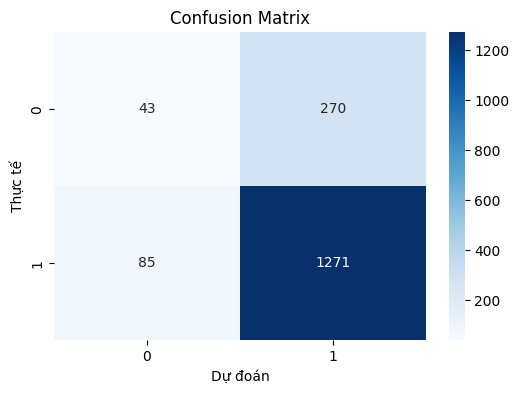

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tách biến độc lập (X) và biến mục tiêu (y)
X = df_processed.drop('loan_status', axis=1)
y = df_processed['loan_status']

# 2. Chia tập Train và Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Chuẩn hóa dữ liệu (BẮT BUỘC cho KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Huấn luyện mô hình KNN
knn = KNeighborsClassifier(n_neighbors= 5)
knn.fit(X_train_scaled, y_train)

# 5. Dự báo trên tập Test
y_pred = knn.predict(X_test_scaled)

# 6. Xuất kết quả báo cáo
print("--- KẾT QUẢ MÔ HÌNH KNN ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Vẽ Ma trận nhầm lẫn (Confusion Matrix) để báo cáo thêm chuyên nghiệp
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

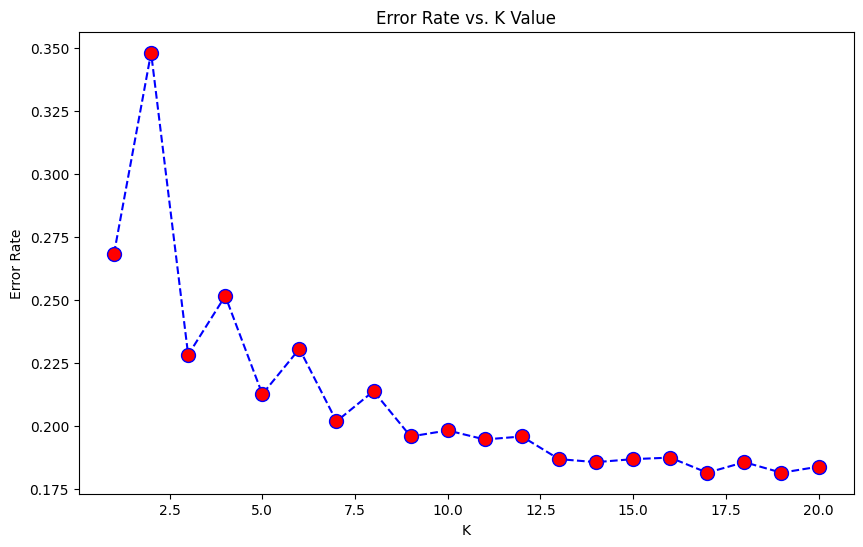

Giá trị K tối ưu nhất là: 17


In [10]:
error_rate = []

# Chạy thử K từ 1 đến 20
for i in range(1, 21):
    knn_test = KNeighborsClassifier(n_neighbors=i)
    knn_test.fit(X_train_scaled, y_train)
    pred_i = knn_test.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

# Vẽ biểu đồ Error Rate
plt.figure(figsize=(10,6))
plt.plot(range(1,21), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

# Tìm K có lỗi thấp nhất
best_k = range(1,21)[error_rate.index(min(error_rate))]
print(f"Giá trị K tối ưu nhất là: {best_k}")

--- KẾT QUẢ MÔ HÌNH KNN ---
Accuracy Score: 0.82

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.11      0.19       313
           1       0.83      0.98      0.90      1356

    accuracy                           0.82      1669
   macro avg       0.71      0.55      0.54      1669
weighted avg       0.78      0.82      0.76      1669



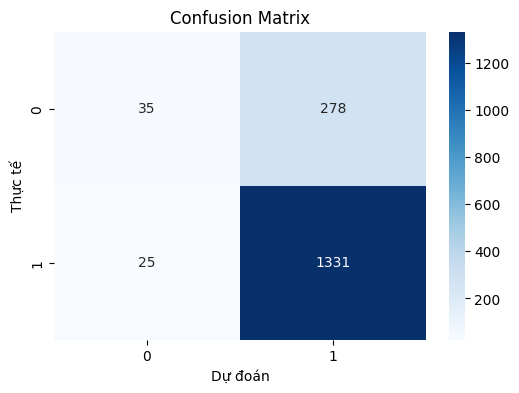

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tách biến độc lập (X) và biến mục tiêu (y)
X = df_processed.drop('loan_status', axis=1)
y = df_processed['loan_status']

# 2. Chia tập Train và Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Chuẩn hóa dữ liệu (BẮT BUỘC cho KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Huấn luyện mô hình KNN
knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(X_train_scaled, y_train)

# 5. Dự báo trên tập Test
y_pred = knn.predict(X_test_scaled)

# 6. Xuất kết quả báo cáo
print("--- KẾT QUẢ MÔ HÌNH KNN ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Vẽ Ma trận nhầm lẫn (Confusion Matrix) để báo cáo thêm chuyên nghiệp
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()